**Logan Marku**

CS 251/2: Data Analysis and Visualization

Spring 2026

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import kmeans

# Breast Cancer and K-Mean Clustering

This project analyzes a breast cancer dataset to evaluate whether unsupervised clustering can identify meaningful patterns in tumor characteristics. The goal is to determine whether patients can be grouped into clinically relevant categories using only feature data, without relying on diagnosis labels. This type of approach is valuable in medical contexts where labeled data may be limited or where exploratory analysis can reveal hidden structure in high-dimensional datasets.

This demonstrates how clustering methods can be used as an exploratory step in medical data analysis and provides a proof-of-concept for how similar techniques could be applied to more advanced tasks such as breast cancer recurrence prediction using gene expression data.

## Breast Cancer Clustering 

## Dataset Overview

# Dataset Description

The dataset used in this extension was originally prepared for the **Women Coders Bootcamp for Social Good**, organized by **Artificial Intelligence for Development in collaboration with UNDP Nepal**. It contains measurements derived from digitized medical images of breast tissue samples.

The dataset features describe important characteristics of the cell nuclei such as:

- radius
- texture
- perimeter
- area
- smoothness
- compactness
- concavity
- concave points
- symmetry
- fractal dimension

For each characteristic, multiple statistical summaries are provided (mean, standard error, and worst value), resulting in a total of **30 numerical predictor variables** for each patient sample.

The diagnosis label indicates whether the tumor is:

- **M** → Malignant  
- **B** → Benign  

The linear programming formulation used to construct these separating planes is described in:

The dataset is also publicly available through the **University of Wisconsin Computer Science dataset repository**, commonly referred to as the **Wisconsin Diagnostic Breast Cancer (WDBC) dataset**. I obtained this dataset from Kaggle. 

Although the dataset includes diagnosis labels, in this project the labels are used **only for evaluation**. The K-means algorithm itself performs **unsupervised clustering**, meaning it groups samples based solely on similarity in the feature space rather than using the diagnosis labels during training.

## Dataset Structure

The output above shows the structure of the breast cancer dataset after loading it into Python.  
The dataset contains **569 samples** and **32 columns**.

Two columns are metadata:
- `id`: a unique identifier for each patient sample  
- `diagnosis`: the label indicating whether the tumor is **malignant (M)** or **benign (B)**  

The remaining **30 columns** are numerical features describing properties of the cell nuclei extracted from breast tissue images. These include measurements such as tumor radius, texture, perimeter, area, smoothness, and concavity.

The table displayed shows the **first five rows of the dataset**, which helps verify that the data has been loaded correctly and gives a preview of the variables available for analysis.

In [15]:
df = pd.read_csv("data/data_breast_cancer.csv")

print("Shape:", df.shape)
print()
print(df.head())
print()
print(df.columns.tolist())

Shape: (569, 32)

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave_points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  radius_worst  texture_worst  perimet

## Feature Matrix and Label Distribution + Data Cleaning and Preprocessing

The dataset is split into two parts before applying K-means clustering:

- **X (feature matrix)** contains the 30 numerical measurements used for clustering.
- **y (label vector)** contains the diagnosis label for each sample.

The shapes confirm that the dataset contains **569 samples**, each with **30 numerical features**.

The diagnosis labels are distributed as follows:

- **212 malignant tumors**
- **357 benign tumors**

Furthermore, before applying K-means clustering, the dataset required preprocessing to ensure meaningful distance-based comparisons. Non-informative fields such as patient ID were removed, and categorical diagnosis labels were encoded numerically for evaluation purposes. Because K-means relies on Euclidean distance, all features were standardized using z-score normalization to prevent variables with larger scales (e.g., area) from dominating the clustering process. This step was critical for ensuring that each feature contributed proportionally to the clustering outcome. Finally, the dataset contained no missing values, allowing the analysis to proceed without imputation.

In [7]:
# diagnosis:
# M = malignant
# B = benign

label_map = {'B': 0, 'M': 1}

y = df['diagnosis'].map(label_map).to_numpy()

# drop non-feature columns
feature_df = df.drop(columns=['id', 'diagnosis'])

X = feature_df.to_numpy(dtype=float)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Malignant count:", np.sum(y == 1))
print("Benign count:", np.sum(y == 0))

X shape: (569, 30)
y shape: (569,)
Malignant count: 212
Benign count: 357


## K-Means Clustering Insights

K-means clustering was run multiple times with different random centroid initializations to improve stability. The best result after **10 runs** produced an inertia of approximately **20.38**.

Inertia measures the average squared distance between each data point and its assigned cluster centroid. Lower inertia indicates more compact and well-defined clusters.

With **k = 2 clusters**, the final cluster sizes were:

- **Cluster 0:** 189 samples  
- **Cluster 1:** 380 samples  

These clusters will next be compared with the actual diagnosis labels to see how well the unsupervised clustering aligns with the benign and malignant tumor categories.

In [ ]:
np.random.seed(0)

km = kmeans.KMeans(X)
km.zscore_normalize()

centroids, labels, inertia = km.cluster_batch(k=2, n_iter=10, verbose=True)

print("Best inertia:", inertia)
print("Cluster counts:", km.cluster_counts())

The best inertia after 10 runs: 20.3787
Best inertia: 20.37866691381783
Cluster counts: [189 380]


## Comparing Clusters to Diagnosis Labels

After clustering the data, the diagnosis labels were used to evaluate how the clusters align with the actual medical categories.

### Cluster Composition

**Cluster 0**
- Total samples: 189  
- Benign: 14  
- Malignant: 175  
- Majority class: Malignant  
- Purity: 0.926  

**Cluster 1**
- Total samples: 380  
- Benign: 343  
- Malignant: 37  
- Majority class: Benign  
- Purity: 0.903  

Each cluster is strongly dominated by one diagnosis class, indicating that the K-means algorithm was able to separate the data in a way that closely matches the true medical labels.

### Cluster-Based Accuracy

By assigning each cluster the diagnosis label that appears most frequently within it, the clustering achieves an approximate accuracy of:

**91.0%**

This shows that the natural structure of the dataset aligns well with the benign vs malignant distinction.

### Confusion Matrix

The confusion matrix summarizes the comparison between the cluster-based predictions and the true diagnosis labels:

|                | Predicted Benign | Predicted Malignant |
|----------------|------------------|---------------------|
| **Actual Benign** | 343 | 14 |
| **Actual Malignant** | 37 | 175 |

This indicates that most benign and malignant samples are grouped correctly by the clustering, even though K-means does not use the diagnosis labels during training.

In [9]:
summary = km.cluster_label_summary(y)

for cluster_id, info in summary.items():
    print(f"Cluster {cluster_id}")
    print(f"  total samples   = {info['total']}")
    print(f"  benign (0)      = {info['class_0']}")
    print(f"  malignant (1)   = {info['class_1']}")
    print(f"  majority class  = {info['majority_class']}")
    print(f"  purity          = {info['purity']:.3f}")
    print()

acc = km.simple_accuracy(y)
cm = km.confusion_matrix_binary(y)

print("Majority-vote clustering accuracy:", acc)
print()
print("Confusion matrix [[TN, FP], [FN, TP]]:")
print(cm)

Cluster 0
  total samples   = 189
  benign (0)      = 14
  malignant (1)   = 175
  majority class  = 1
  purity          = 0.926

Cluster 1
  total samples   = 380
  benign (0)      = 343
  malignant (1)   = 37
  majority class  = 0
  purity          = 0.903

Majority-vote clustering accuracy: 0.9103690685413005

Confusion matrix [[TN, FP], [FN, TP]]:
[[343  14]
 [ 37 175]]


## Elbow Plot for Choosing the Number of Clusters

The elbow plot shows how the **inertia** (mean squared distance between samples and their cluster centroids) changes as the number of clusters \(k\) increases.

As \(k\) increases, inertia decreases because more clusters allow the data to be grouped more tightly. However, after a certain point the improvement becomes much smaller.

In this plot, the largest drop in inertia occurs between **k = 1 and k = 2**, and the curve begins to flatten afterward. This indicates that **two clusters capture a large portion of the structure in the data**, which aligns well with the two diagnosis categories in the dataset: **benign and malignant**.

Because of this clear elbow in the curve, **k = 2** is a reasonable and interpretable choice for clustering this dataset.

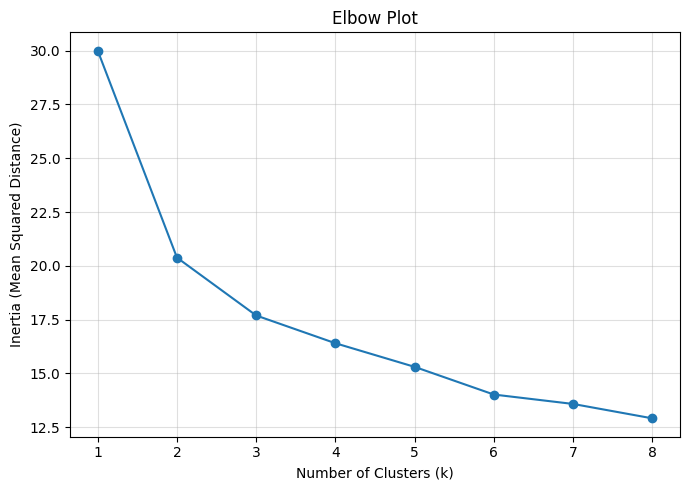

[np.float64(30.0),
 np.float64(20.3790567887911),
 np.float64(17.689703301815165),
 np.float64(16.399419756230763),
 np.float64(15.300670606355457),
 np.float64(14.01399797619712),
 np.float64(13.576886329040203),
 np.float64(12.907655250237433)]

In [10]:
km_elbow = kmeans.KMeans(X)
km_elbow.zscore_normalize()
km_elbow.elbow_plot(max_k=8)

## Visualizing Clusters in Feature Space

This scatter plot shows the K-means clustering results projected onto two features:

- **radius_mean** (x-axis)
- **concavity_mean** (y-axis)

Each point represents a patient sample, and the colors indicate which cluster the sample was assigned to by the K-means algorithm. The black **X markers** represent the centroids (the center of each cluster).

Even though the clustering was performed in the full **30-dimensional feature space**, plotting two features helps visualize how the algorithm separates the data.

The plot shows that one cluster tends to contain samples with **larger tumor radius and higher concavity**, while the other cluster contains samples with **smaller radius and lower concavity**. These differences in tumor structure help explain why the clusters correspond closely to malignant and benign diagnoses.

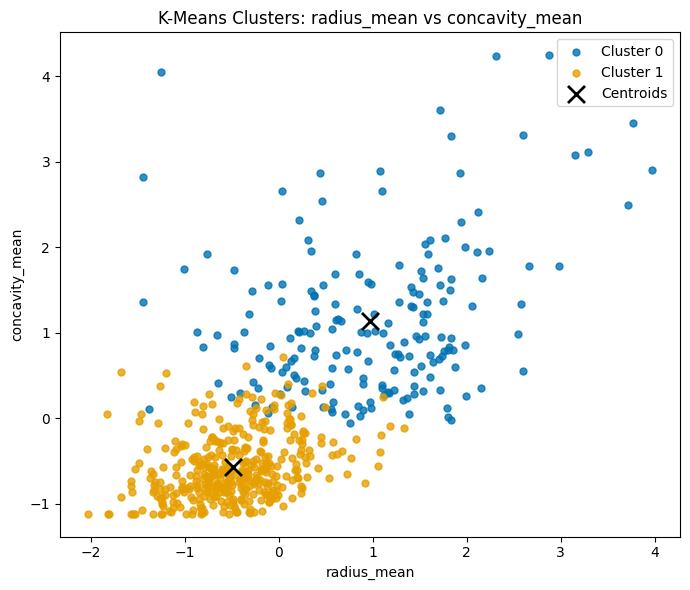

In [11]:
feature_names = feature_df.columns.tolist()

x_name = 'radius_mean'
y_name = 'concavity_mean'

x_idx = feature_names.index(x_name)
y_idx = feature_names.index(y_name)

km.plot_feature_clusters(
    x_index=x_idx,
    y_index=y_idx,
    x_label=x_name,
    y_label=y_name
)

## Actual Diagnosis Distribution

This scatter plot shows the same two features used previously, **radius_mean** and **concavity_mean**, but now the points are colored according to the **true diagnosis labels** rather than the K-means cluster assignments.

Each point represents a tumor sample:

- **Benign tumors** tend to appear in the lower-left region of the plot, where both radius and concavity values are smaller.
- **Malignant tumors** tend to appear in the upper-right region, where tumors generally have larger radii and higher concavity values.

Comparing this plot with the earlier **K-means clustering visualization** shows that the clusters discovered by the algorithm closely resemble the true diagnosis grouping. This demonstrates that the underlying feature patterns in the dataset naturally separate benign and malignant tumors, which is why unsupervised clustering performs well on this data.

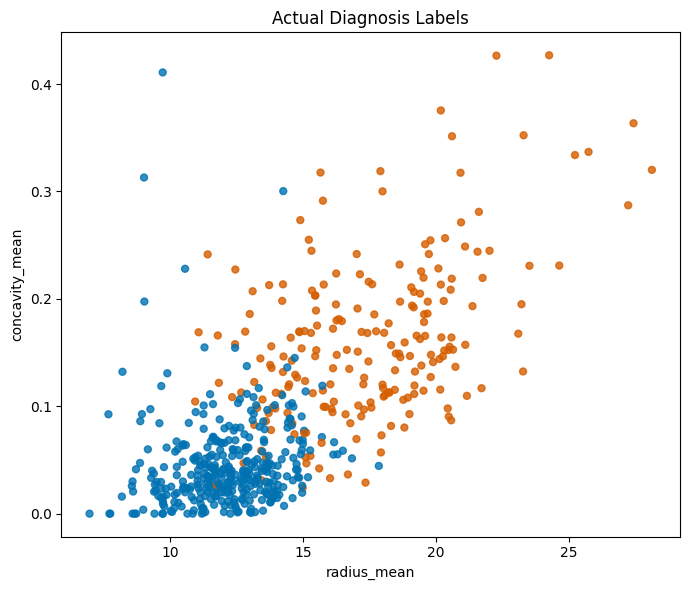

In [12]:
colors = np.where(y == 1, "#D55E00", "#0072B2")  # malignant, benign

plt.figure(figsize=(7, 6))
plt.scatter(X[:, x_idx], X[:, y_idx], c=colors, s=25, alpha=0.8)

plt.xlabel(x_name)
plt.ylabel(y_name)
plt.title("Actual Diagnosis Labels")
plt.tight_layout()
plt.show()

## Class Composition Within Each Cluster

This stacked bar chart shows how **benign and malignant samples are distributed within each K-means cluster**.

- **Cluster 0** contains mostly **malignant tumors**, with only a small number of benign samples.
- **Cluster 1** contains mostly **benign tumors**, with relatively few malignant samples.

The strong separation between the two classes demonstrates that the clusters produced by the K-means algorithm align closely with the actual medical diagnosis labels.

This visualization makes it easier to interpret the clustering results by clearly showing how each cluster corresponds to a different tumor category. Even though K-means does not use the diagnosis labels during clustering, the feature patterns in the dataset naturally lead to clusters that largely match the benign vs malignant distinction.

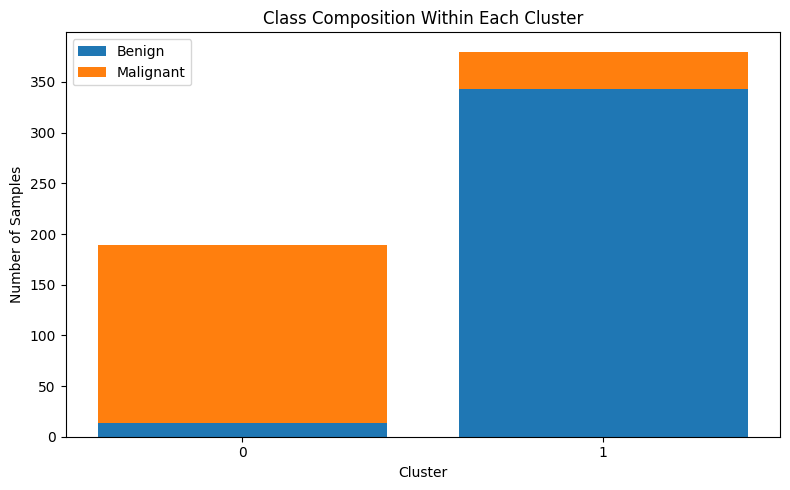

In [13]:
km.plot_cluster_label_bars(
    y,
    class_names=('Benign', 'Malignant')
)

## Cluster Centroid Interpretation

The table above shows the **centroid values for selected features** in each cluster after the data was **z-score normalized**. Because the features were standardized, the values represent how far each cluster's average is from the overall dataset mean in units of standard deviations.

Tumors grouped in Cluster 0 consistently exhibit larger size and higher structural irregularity, which are clinically associated with malignant growth. This suggests that the clustering algorithm is capturing meaningful biological distinctions in tumor morphology. In contrast, Cluster 1 contains tumors with smaller and more regular structures, aligning with benign cases. These patterns indicate that the underlying feature space naturally separates tumors along clinically relevant dimensions.

Put simply, **Cluster 0** has positive values across these features, meaning tumors in this cluster tend to have:
- larger **radius**
- larger **perimeter**
- larger **area**
- higher **concavity**

These characteristics are commonly associated with **malignant tumors**, which helps explain why this cluster is mostly malignant.

**Cluster 1** has negative values for these same features, meaning tumors in this cluster tend to have **smaller and less irregular cell structures**, which are more typical of **benign tumors**.

This comparison shows how differences in tumor size and shape contribute to the separation between the two clusters.

In [14]:
# Since KMeans was run on normalized data, these are z-score centroids
selected_features = ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'concavity_mean']

selected_idx = [feature_names.index(f) for f in selected_features]

centroid_df = pd.DataFrame(
    km.get_centroids()[:, selected_idx],
    columns=selected_features,
    index=[f'Cluster {i}' for i in range(km.k)]
)

centroid_df

,radius_mean,texture_mean,perimeter_mean,area_mean,concavity_mean
Cluster 0,0.973976,0.481514,1.006635,0.963527,1.139429
Cluster 1,-0.484425,-0.239490,-0.500668,-0.479228,-0.566716


## Key Insights and their Implications

These results demonstrate that unsupervised clustering can effectively identify clinically meaningful structure in tumor data, even without access to diagnosis labels. The ability of K-means to separate tumors into groups that closely align with clinical diagnoses indicates that the underlying feature space contains strong, naturally occurring structure. In practice, this type of approach could help highlight patterns in patient data that warrant further investigation, allowing researchers or clinicians to prioritize certain cases or identify high-risk groups more efficiently. Rather than replacing existing diagnostic methods, clustering can act as an initial filtering or pattern-discovery step that supports more targeted, downstream analysis.

At the same time, it is important to emphasize that this approach should not be used for self-diagnosis or as a standalone clinical tool. While the clustering results align closely with known diagnoses, the model operates without medical context and lacks the robustness and validation required for real-world decision-making. Any insights derived from this analysis should be interpreted as supportive signals that help guide medical professionals, not as definitive conclusions. In a clinical setting, methods like this are most valuable when used to assist doctors in focusing their attention and informing further testing, rather than replacing expert judgment or established diagnostic procedures.

While the clustering results are strong, there are several important limitations to consider. First, K-means assumes that clusters are roughly spherical and evenly sized, which may not fully capture the complex, high-dimensional structure of biological data. The algorithm is also sensitive to initialization, meaning different random starting points can lead to different results, which is why multiple runs were required to achieve stability. Additionally, while the clusters align closely with diagnosis labels, K-means is an unsupervised method and does not have the predictive power or reliability of supervised models trained directly on labeled outcomes. From a data perspective, this analysis is limited to a single, relatively clean and well-structured dataset, which may not reflect the variability, noise, and missing values commonly found in real-world clinical data. As a result, the performance observed here may not generalize as effectively to more complex or less curated datasets.